In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from pathlib import Path
from IPython.display import display

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"

TRAIN_END_YEAR = 2017
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

print("Data path:", DATA_PATH)

Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv


In [2]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def build_prediction_frame(model, df, target_col, target_label):
    pred_df = df.copy()

    pred_df[f"predicted_{target_label}_log"] = model.predict(pred_df)
    pred_df[f"actual_{target_label}_log"] = pred_df[target_col]

    pred_df[f"predicted_{target_label}_level"] = np.exp(pred_df[f"predicted_{target_label}_log"])
    pred_df[f"actual_{target_label}_level"] = np.exp(pred_df[f"actual_{target_label}_log"])

    pred_df["feature_year"] = pred_df["year"].astype(int)
    pred_df["target_year"] = pred_df["feature_year"] + 1
    pred_df["absolute_error"] = np.abs(
        pred_df[f"actual_{target_label}_level"] - pred_df[f"predicted_{target_label}_level"]
    )
    pred_df["absolute_percentage_error_pct"] = (
        pred_df["absolute_error"] / pred_df[f"actual_{target_label}_level"]
    ) * 100

    return pred_df


def evaluate_model(model, train_df, test_df, target_col, model_name, target_label):
    train_pred = build_prediction_frame(model, train_df, target_col, target_label)
    test_pred = build_prediction_frame(model, test_df, target_col, target_label)

    train_level_metrics = regression_metrics(
        train_pred[f"actual_{target_label}_level"],
        train_pred[f"predicted_{target_label}_level"],
    )
    test_level_metrics = regression_metrics(
        test_pred[f"actual_{target_label}_level"],
        test_pred[f"predicted_{target_label}_level"],
    )

    train_log_metrics = regression_metrics(
        train_pred[f"actual_{target_label}_log"],
        train_pred[f"predicted_{target_label}_log"],
    )
    test_log_metrics = regression_metrics(
        test_pred[f"actual_{target_label}_log"],
        test_pred[f"predicted_{target_label}_log"],
    )

    metrics_df = pd.DataFrame([
        {
            "Model": model_name,
            "Split": "Train",
            "Scale": "Level",
            "n_obs": len(train_pred),
            **train_level_metrics,
        },
        {
            "Model": model_name,
            "Split": "Train",
            "Scale": "Log",
            "n_obs": len(train_pred),
            **train_log_metrics,
        },
        {
            "Model": model_name,
            "Split": "Test",
            "Scale": "Level",
            "n_obs": len(test_pred),
            **test_level_metrics,
        },
        {
            "Model": model_name,
            "Split": "Test",
            "Scale": "Log",
            "n_obs": len(test_pred),
            **test_log_metrics,
        },
    ]).round(4)

    return train_pred, test_pred, metrics_df

In [3]:
base_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "log_gdp_per_capita",
    "target_log_gdp_next_year",
]

df = pd.read_csv(DATA_PATH, usecols=base_cols).copy()

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "log_gdp_per_capita",
    "target_log_gdp_next_year",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().copy()
df["year"] = df["year"].astype(int)

print("Shape:", df.shape)
print("Year range:", int(df["year"].min()), "-", int(df["year"].max()))
display(df.head())

Shape: (11159, 10)
Year range: 1960 - 2022


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year
0,Aruba,ABW,Latin America & Caribbean,1986,"6,767.5592",71.8310,"59,931.0000",8.8199,11.0009,9.0172
1,Aruba,ABW,Latin America & Caribbean,1987,"8,244.0457",72.4480,"59,159.0000",9.0172,10.9880,9.2160
2,Aruba,ABW,Latin America & Caribbean,1988,"10,056.2614",72.5190,"59,331.0000",9.2160,10.9909,9.3507
3,Aruba,ABW,Latin America & Caribbean,1989,"11,507.2172",72.5310,"60,443.0000",9.3507,11.0095,9.4082
4,Aruba,ABW,Latin America & Caribbean,1990,"12,187.5364",72.5460,"62,753.0000",9.4082,11.0470,9.4905


In [4]:
# Hướng 1:
# target = log GDP per capita năm sau

df_pc = df.copy()
df_pc["target_log_gdp_pc_next_year"] = df_pc["target_log_gdp_next_year"]

formula_pc = "target_log_gdp_pc_next_year ~ log_population_total + life_expectancy_years"
model_name_pc = "Direction 1 - GDP per Capita"

train_pc = df_pc[df_pc["year"] <= TRAIN_END_YEAR].copy()
test_pc = df_pc[
    (df_pc["year"] >= TEST_START_YEAR) & (df_pc["year"] <= TEST_END_YEAR)
].copy()

print("Direction 1 train:", train_pc.shape)
print("Direction 1 test:", test_pc.shape)

Direction 1 train: (10117, 11)
Direction 1 test: (1042, 11)


In [5]:
model_pc = smf.ols(formula=formula_pc, data=train_pc).fit(cov_type="HC3")

print(model_name_pc)
print(model_pc.summary())

Direction 1 - GDP per Capita
                                 OLS Regression Results                                
Dep. Variable:     target_log_gdp_pc_next_year   R-squared:                       0.720
Model:                                     OLS   Adj. R-squared:                  0.719
Method:                          Least Squares   F-statistic:                     9624.
Date:                         Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                                 15:58:58   Log-Likelihood:                -13545.
No. Observations:                        10117   AIC:                         2.710e+04
Df Residuals:                            10114   BIC:                         2.712e+04
Df Model:                                    2                                         
Covariance Type:                           HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-

In [6]:
coef_ci_pc = model_pc.conf_int()

coef_table_pc = pd.DataFrame({
    "term": model_pc.params.index,
    "coefficient": model_pc.params.values,
    "std_error": model_pc.bse.values,
    "t_value": model_pc.tvalues.values,
    "p_value": model_pc.pvalues.values,
    "ci_lower": coef_ci_pc[0].values,
    "ci_upper": coef_ci_pc[1].values,
}).round(6)

display(coef_table_pc)

,term,coefficient,std_error,t_value,p_value,ci_lower,ci_upper
0,Intercept,0.6223,0.0951,6.5407,0.0000,0.4358,0.8088
1,log_population_total,-0.0945,0.0041,-22.9262,0.0000,-0.1026,-0.0864
2,life_expectancy_years,0.1304,0.0010,133.4215,0.0000,0.1284,0.1323


In [7]:
train_pred_pc, test_pred_pc, metrics_pc = evaluate_model(
    model=model_pc,
    train_df=train_pc,
    test_df=test_pc,
    target_col="target_log_gdp_pc_next_year",
    model_name=model_name_pc,
    target_label="gdp_pc_next_year",
)

display(metrics_pc)

,Model,Split,Scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Direction 1 - GDP per Capita,Train,Level,10117,"5,260.2406","13,338.5140",97.7080,0.3779
1,Direction 1 - GDP per Capita,Train,Log,10117,0.7380,0.9230,10.2732,0.7195
2,Direction 1 - GDP per Capita,Test,Level,1042,"12,277.6584","25,904.9196",60.9438,0.2423
3,Direction 1 - GDP per Capita,Test,Log,1042,0.6899,0.8424,7.7022,0.6699


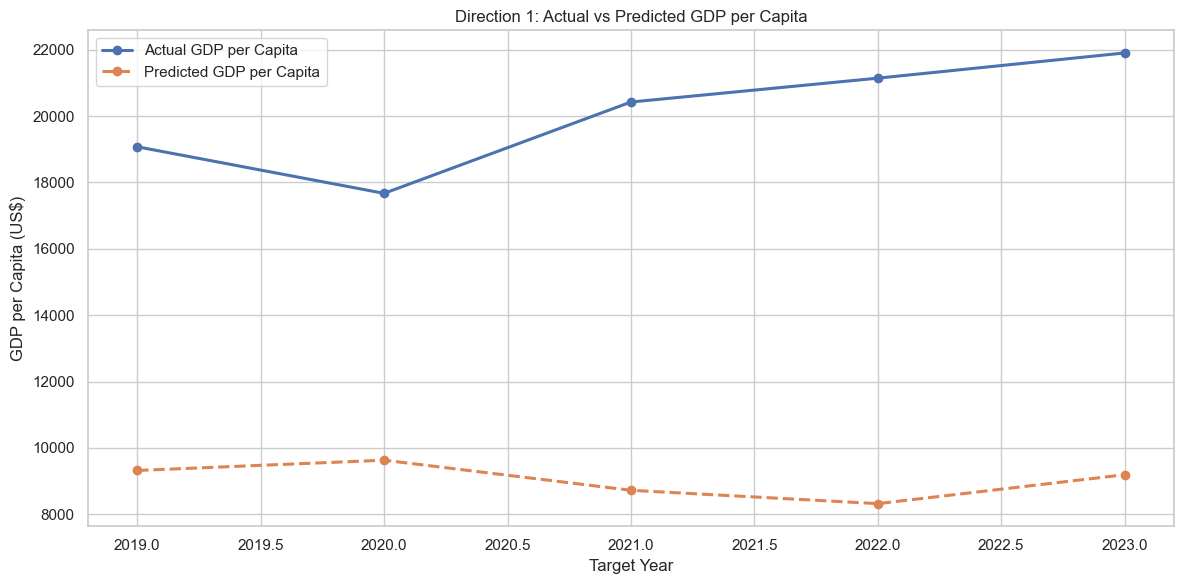

In [8]:
plot_pc = (
    test_pred_pc.groupby("target_year", as_index=False)[
        ["actual_gdp_pc_next_year_level", "predicted_gdp_pc_next_year_level"]
    ]
    .mean()
    .sort_values("target_year")
)

plt.figure(figsize=(12, 6))
plt.plot(
    plot_pc["target_year"],
    plot_pc["actual_gdp_pc_next_year_level"],
    marker="o",
    linewidth=2.2,
    label="Actual GDP per Capita",
)
plt.plot(
    plot_pc["target_year"],
    plot_pc["predicted_gdp_pc_next_year_level"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="Predicted GDP per Capita",
)
plt.title("Direction 1: Actual vs Predicted GDP per Capita")
plt.xlabel("Target Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Hướng 2:
# total_gdp = gdp_per_capita * population
# target = log total GDP năm sau

df_total = df.copy()

df_total["total_gdp_usd"] = df_total["gdp_per_capita_usd"] * df_total["population_total"]
df_total["log_total_gdp_usd"] = np.log(df_total["total_gdp_usd"])

df_total = df_total.sort_values(["country_code", "year"]).copy()
df_total["target_log_total_gdp_next_year"] = (
    df_total.groupby("country_code")["log_total_gdp_usd"].shift(-1)
)

df_total = df_total.dropna(subset=["target_log_total_gdp_next_year"]).copy()

formula_total = "target_log_total_gdp_next_year ~ log_population_total + life_expectancy_years"
model_name_total = "Direction 2 - Total GDP"

train_total = df_total[df_total["year"] <= TRAIN_END_YEAR].copy()
test_total = df_total[
    (df_total["year"] >= TEST_START_YEAR) & (df_total["year"] <= TEST_END_YEAR)
].copy()

print("Direction 2 train:", train_total.shape)
print("Direction 2 test:", test_total.shape)

display(
    df_total[
        [
            "country_name",
            "country_code",
            "year",
            "gdp_per_capita_usd",
            "population_total",
            "total_gdp_usd",
            "log_total_gdp_usd",
            "target_log_total_gdp_next_year",
        ]
    ].head()
)

Direction 2 train: (10114, 13)
Direction 2 test: (831, 13)


,country_name,country_code,year,gdp_per_capita_usd,population_total,total_gdp_usd,log_total_gdp_usd,target_log_total_gdp_next_year
0,Aruba,ABW,1986,"6,767.5592","59,931.0000","405,586,592.1788",19.8208,20.0052
1,Aruba,ABW,1987,"8,244.0457","59,159.0000","487,709,497.2067",20.0052,20.2068
2,Aruba,ABW,1988,"10,056.2614","59,331.0000","596,648,044.6927",20.2068,20.3602
3,Aruba,ABW,1989,"11,507.2172","60,443.0000","695,530,726.2570",20.3602,20.4551
4,Aruba,ABW,1990,"12,187.5364","62,753.0000","764,804,469.2737",20.4551,20.5864


In [10]:
model_total = smf.ols(formula=formula_total, data=train_total).fit(cov_type="HC3")

print(model_name_total)
print(model_total.summary())

Direction 2 - Total GDP
                                  OLS Regression Results                                  
Dep. Variable:     target_log_total_gdp_next_year   R-squared:                       0.871
Model:                                        OLS   Adj. R-squared:                  0.871
Method:                             Least Squares   F-statistic:                 3.025e+04
Date:                            Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                                    16:00:49   Log-Likelihood:                -13546.
No. Observations:                           10114   AIC:                         2.710e+04
Df Residuals:                               10111   BIC:                         2.712e+04
Df Model:                                       2                                         
Covariance Type:                              HC3                                         
                            coef    std err          z      P>|z| 

In [11]:
coef_ci_total = model_total.conf_int()

coef_table_total = pd.DataFrame({
    "term": model_total.params.index,
    "coefficient": model_total.params.values,
    "std_error": model_total.bse.values,
    "t_value": model_total.tvalues.values,
    "p_value": model_total.pvalues.values,
    "ci_lower": coef_ci_total[0].values,
    "ci_upper": coef_ci_total[1].values,
}).round(6)

display(coef_table_total)

,term,coefficient,std_error,t_value,p_value,ci_lower,ci_upper
0,Intercept,0.6711,0.0947,7.0875,0.0000,0.4855,0.8566
1,log_population_total,0.9056,0.0041,219.7788,0.0000,0.8975,0.9137
2,life_expectancy_years,0.1299,0.0010,133.9494,0.0000,0.1280,0.1318


In [12]:
train_pred_total, test_pred_total, metrics_total = evaluate_model(
    model=model_total,
    train_df=train_total,
    test_df=test_total,
    target_col="target_log_total_gdp_next_year",
    model_name=model_name_total,
    target_label="total_gdp_next_year",
)

display(metrics_total)

,Model,Split,Scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Direction 2 - Total GDP,Train,Level,10114,"105,973,248,675.5306","674,296,822,440.9908",97.7787,0.4138
1,Direction 2 - Total GDP,Train,Log,10114,0.7380,0.9235,3.2994,0.8707
2,Direction 2 - Total GDP,Test,Level,831,"273,122,663,279.2718","1,563,906,144,299.1826",60.1556,0.4091
3,Direction 2 - Total GDP,Test,Log,831,0.6755,0.8218,2.7875,0.8784


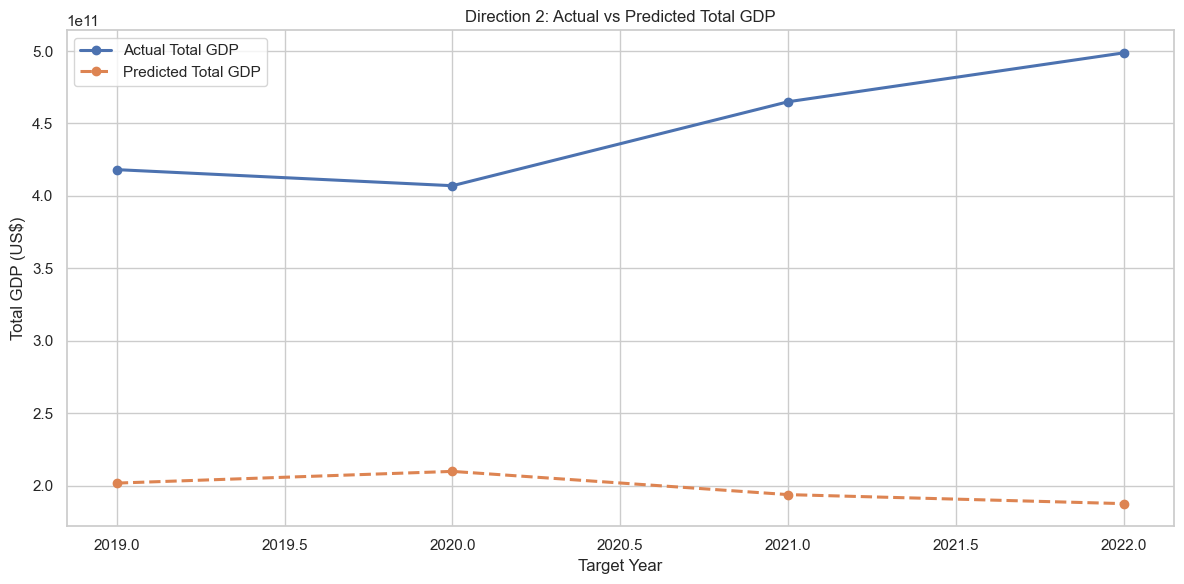

In [13]:
plot_total = (
    test_pred_total.groupby("target_year", as_index=False)[
        ["actual_total_gdp_next_year_level", "predicted_total_gdp_next_year_level"]
    ]
    .mean()
    .sort_values("target_year")
)

plt.figure(figsize=(12, 6))
plt.plot(
    plot_total["target_year"],
    plot_total["actual_total_gdp_next_year_level"],
    marker="o",
    linewidth=2.2,
    label="Actual Total GDP",
)
plt.plot(
    plot_total["target_year"],
    plot_total["predicted_total_gdp_next_year_level"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="Predicted Total GDP",
)
plt.title("Direction 2: Actual vs Predicted Total GDP")
plt.xlabel("Target Year")
plt.ylabel("Total GDP (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
comparison_df = pd.concat([metrics_pc, metrics_total], ignore_index=True)

comparison_test_only = comparison_df[comparison_df["Split"] == "Test"].copy()
display(comparison_test_only)

,Model,Split,Scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
2,Direction 1 - GDP per Capita,Test,Level,1042,"12,277.6584","25,904.9196",60.9438,0.2423
3,Direction 1 - GDP per Capita,Test,Log,1042,0.6899,0.8424,7.7022,0.6699
6,Direction 2 - Total GDP,Test,Level,831,"273,122,663,279.2718","1,563,906,144,299.1826",60.1556,0.4091
7,Direction 2 - Total GDP,Test,Log,831,0.6755,0.8218,2.7875,0.8784


In [15]:
summary_compare = pd.DataFrame([
    {
        "Direction": "GDP per Capita",
        "Target": "log GDP per capita năm sau",
        "Formula": "target_log_gdp_pc_next_year ~ log_population_total + life_expectancy_years",
        "Economic meaning": "Phản ánh mức sống / năng suất tốt hơn",
        "Interpretability": "Cao",
        "Recommended": "Yes",
    },
    {
        "Direction": "Total GDP",
        "Target": "log Total GDP năm sau",
        "Formula": "target_log_total_gdp_next_year ~ log_population_total + life_expectancy_years",
        "Economic meaning": "Phản ánh quy mô nền kinh tế",
        "Interpretability": "Trung bình",
        "Recommended": "Use as comparison",
    },
])

display(summary_compare)

,Direction,Target,Formula,Economic meaning,Interpretability,Recommended
0,GDP per Capita,log GDP per capita năm sau,target_log_gdp_pc_next_year ~ log_population_t...,Phản ánh mức sống / năng suất tốt hơn,Cao,Yes
1,Total GDP,log Total GDP năm sau,target_log_total_gdp_next_year ~ log_populatio...,Phản ánh quy mô nền kinh tế,Trung bình,Use as comparison
